# Train and Tune XGBoost Model Non-Deterministic (Parallel)

In [1]:
from pathlib import Path

import optuna.visualization as vis
import pandas as pd

from config.config import Config
from src.data import time_series_split
from src.models.factory import Experiment
from src.models.xgboost import XGBoost
from src.plots import plot_forecast_diagnostics, plot_forecast_overlay, plot_test_overlay, plot_val_overlay, plot_val_test_overlay
from src.runners import run_experiments
from src.utils import set_seed

In [2]:
cfg = Config(Path("../config/config.yaml"))
SEED = cfg.runtime.seed
HORIZON = cfg.runtime.horizon
rng = set_seed(SEED)

2025-09-04 16:35:09,356 - INFO - src.utils - Global random seed set to 42


In [3]:
df_full = pd.read_csv(Path(cfg.data.processed_dir) / "features_full.csv")

In [4]:
MODEL_NAME = "xgboost"

In [6]:
experiments = [
    Experiment(
        name=MODEL_NAME,
        build=lambda horizon, seed: XGBoost(horizon=horizon,random_state=seed),
        include_sentiment=True,
    )
]

In [7]:
results = run_experiments(df_full, Path(cfg.data.processed_dir), experiments, HORIZON, SEED, n_trials=1, n_splits=2)

2025-09-04 16:35:09,425 - INFO - ModelTrainer - Initialized ModelTrainer for model: xgboost
2025-09-04 16:36:19,119 - INFO - ModelTrainer - Initialized ModelTrainer for model: xgboost
2025-09-04 16:37:16,313 - INFO - ModelTrainer - Evaluating model...


In [8]:
train, val, test, forecast = time_series_split(df_full, train_ratio=0.8, val_ratio=0.1, horizon=HORIZON)

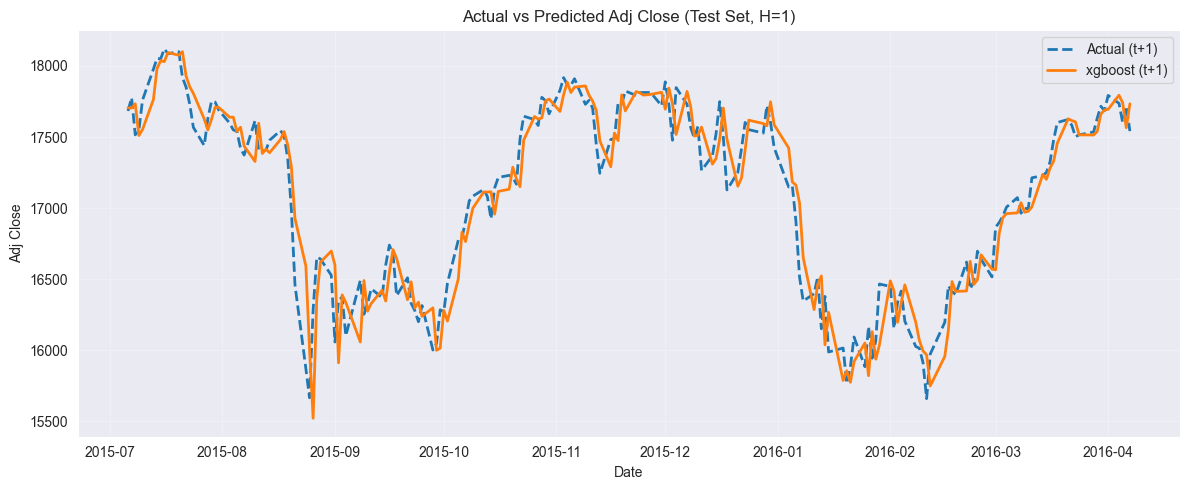

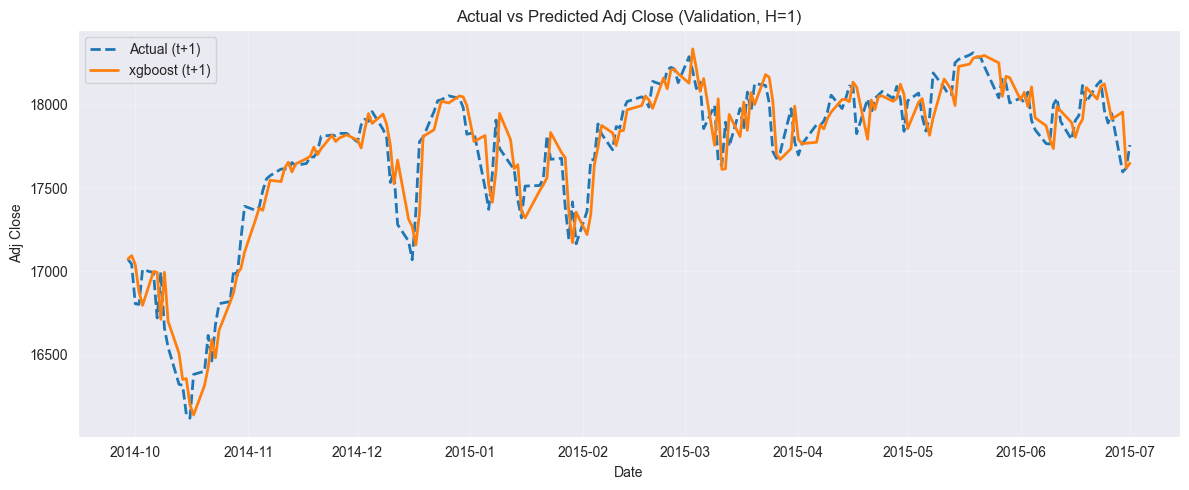

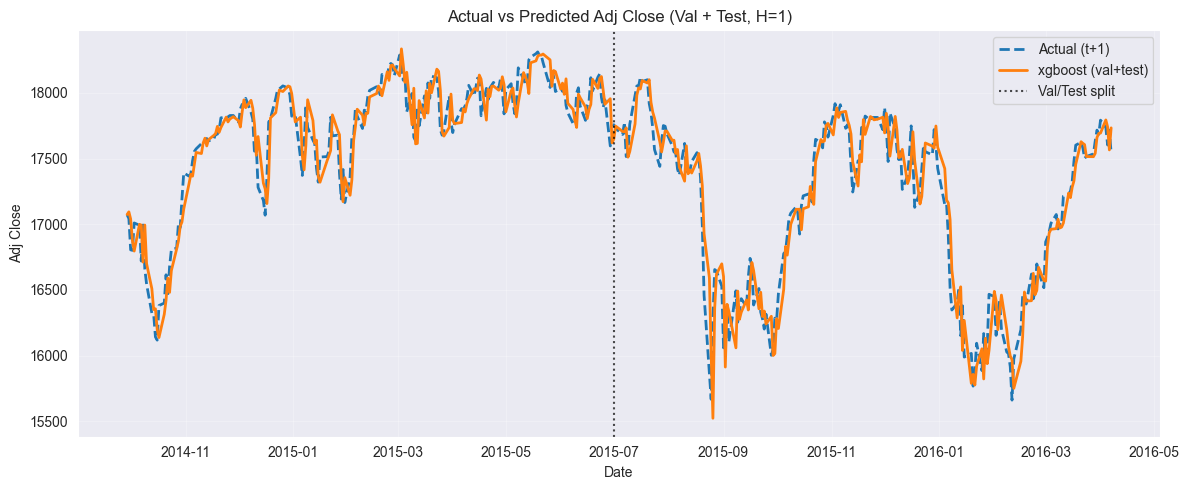

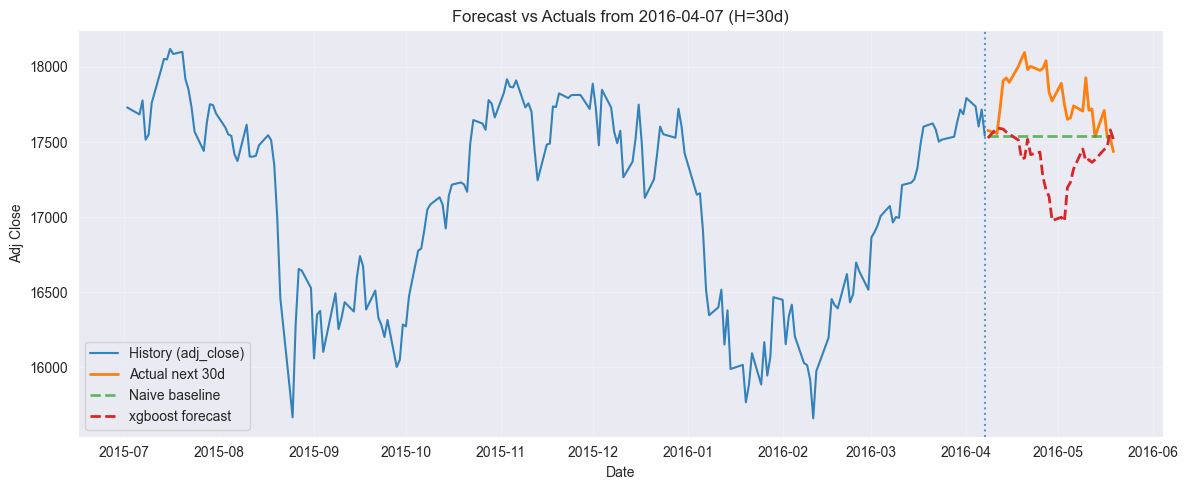

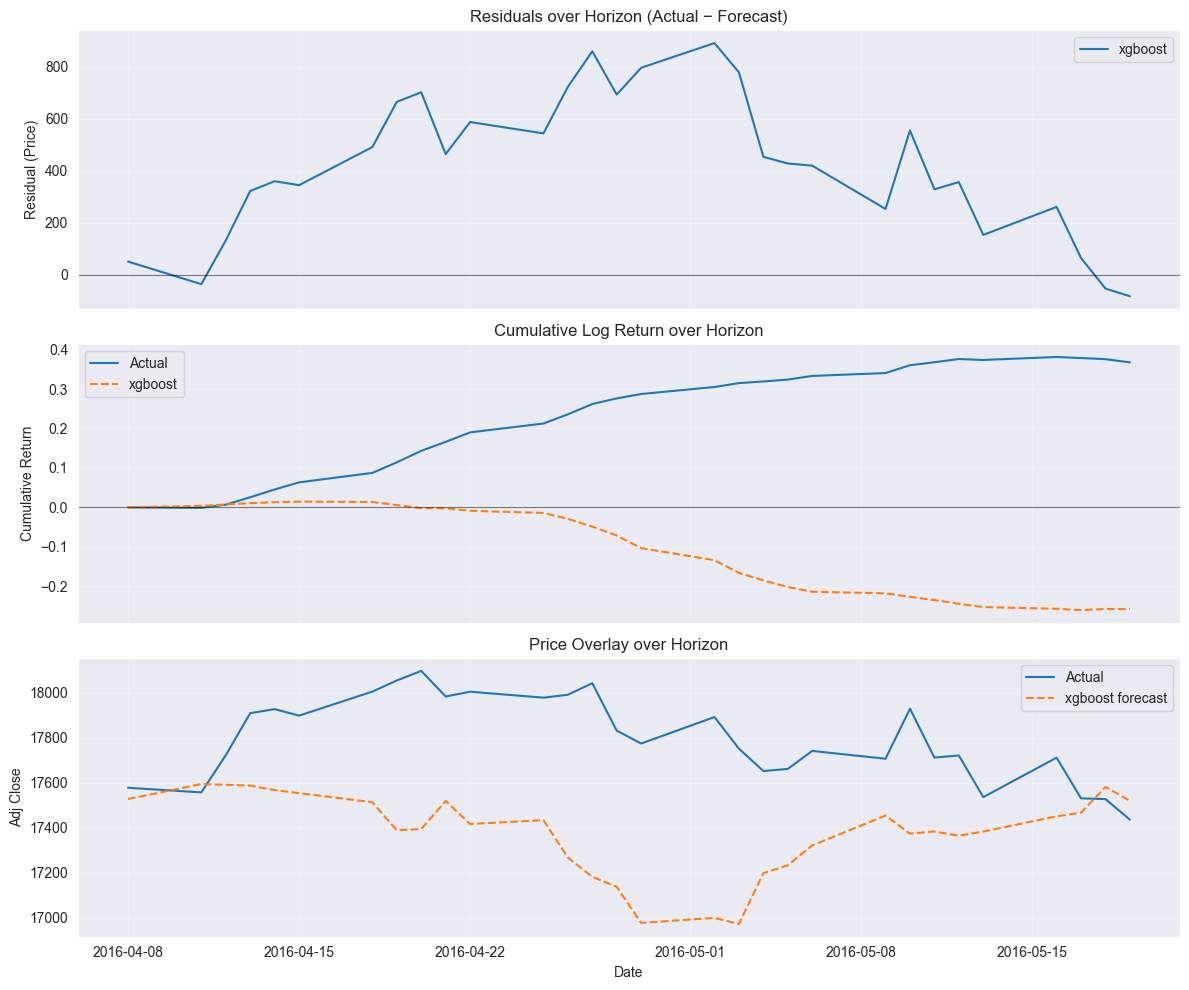

In [9]:
plot_test_overlay(test, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_actual_vs_predicted_adj_close.png")
plot_val_overlay(val, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_actual_vs_predicted_adj_close_val.png")
plot_val_test_overlay(val, test, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_actual_vs_predicted_adj_close_val_test.png")
plot_forecast_overlay(test, forecast, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_forecast.png")
plot_forecast_diagnostics(forecast, test, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_forecast_diagnostics.png")

In [10]:
pd.DataFrame(results[0]["best_params"], index=[0])

,n_estimators,learning_rate,max_depth,subsample,colsample_bytree,min_child_weight,reg_alpha,reg_lambda,gamma,early_stopping_rounds,max_bin,grow_policy,objective,eval_metric,tree_method,max_leaves,random_state
0,1600,0.035221,6,0.740825,0.858589,0.922606,1.645428,4.152625,4.866472,200,448,depthwise,reg:squarederror,rmse,hist,0,42


In [11]:
pd.DataFrame(results[0]["metrics"]["test"], index=[0])

,mae,mse,rmse,smape,r2
0,566.173534,510529.492241,714.513465,1.526576,0.038719


In [12]:
study = results[0]["study"]

vis.plot_optimization_history(study).show()
vis.plot_param_importances(study).show()

ValueError: Cannot evaluate parameter importances with only a single trial.